# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-003 |
| **Nama Eksperimen** | Data Cleaning |
| **Dataset** | hour.csv (Bike Sharing Dataset — UCI ML Repository) |
| **Tujuan Notebook** | Memastikan dataset siap digunakan untuk feature engineering dan modeling |
| **Tanggal Pengerjaan** | 21 Juli 2026 |
| **Versi Notebook** | 1.0.0 |
| **Author** | GAKUSEI Najib |
| **Prasyarat** | EXP-001 Data Understanding ✅, EXP-002 EDA ✅ |

---

## Daftar Isi

1. [Tujuan Eksperimen](#1-tujuan-eksperimen)
2. [Import Library](#2-import-library)
3. [Load Dataset](#3-load-dataset)
4. [Validasi Missing Value](#4-validasi-missing-value)
5. [Validasi Duplicate](#5-validasi-duplicate)
6. [Validasi & Konversi Tipe Data](#6-validasi--konversi-tipe-data)
7. [Validasi Rentang Nilai](#7-validasi-rentang-nilai)
8. [Analisis & Penanganan Outlier](#8-analisis--penanganan-outlier)
9. [Penghapusan Feature yang Tidak Digunakan](#9-penghapusan-feature-yang-tidak-digunakan)
10. [Dataset Final & Laporan Cleaning](#10-dataset-final--laporan-cleaning)
11. [Simpan Dataset Hasil Cleaning](#11-simpan-dataset-hasil-cleaning)
12. [Next Step](#12-next-step)

---

## 1. Tujuan Eksperimen

### Tujuan

Memastikan dataset bersih dan siap digunakan untuk proses feature engineering dan modeling dengan melakukan serangkaian validasi serta transformasi yang diperlukan.

---

### Hipotesis

> Dataset relatif bersih namun masih memerlukan validasi terhadap outlier, tipe data, serta konsistensi nilai.

---

### Konteks dari Eksperimen Sebelumnya

Berdasarkan temuan pada **EXP-001** dan **EXP-002**, berikut yang perlu dilakukan:

| Temuan | Aksi |
|--------|------|
| `dteday` bertipe `object` | Konversi ke `datetime` |
| `casual` & `registered` menyebabkan data leakage | Hapus dari dataset |
| `instant` hanya identifier tanpa nilai prediktif | Hapus dari dataset |
| Distribusi `cnt` right-skewed dengan outlier di nilai tinggi | Analisis & dokumentasi |
| Kolom kategorikal (season, yr, dll.) bertipe integer | Dokumentasi, tanpa konversi (model-agnostic) |

---

### Output yang Diharapkan

- Dataset bersih yang siap digunakan pada EXP-004
- File: `data/processed_data.csv`
- Laporan ringkasan proses cleaning

---

### Acceptance Criteria

| Kriteria | Keterangan |
|----------|------------|
| Dataset siap modeling | Feature tidak berguna sudah dihapus |
| Tipe data sudah benar | `dteday` sudah `datetime` |
| Tidak ada missing value | Diverifikasi ulang |
| Tidak ada duplicate | Diverifikasi ulang |
| Outlier sudah dianalisis | Keputusan retain/remove terdokumentasi |
| Dataset berhasil disimpan | `data/processed_data.csv` tersedia |

---

## 2. Import Library

Library yang dibutuhkan pada tahap Data Cleaning adalah `pandas`, `numpy`, dan `matplotlib`/`seaborn` untuk visualisasi distribusi saat penanganan outlier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Library berhasil diimport.')
print(f'Versi pandas : {pd.__version__}')
print(f'Versi numpy  : {np.__version__}')

Library berhasil diimport.
Versi pandas : 2.3.3
Versi numpy  : 2.0.2


---

## 3. Load Dataset

Dataset dimuat langsung dari file raw `hour.csv`. Seluruh proses cleaning dilakukan terhadap salinan DataFrame sehingga data asli tidak berubah.

In [2]:
# Definisikan path
DATA_PATH      = '../data/hour.csv'
OUTPUT_PATH    = '../data/processed_data.csv'

# Load dataset raw
df_raw = pd.read_csv(DATA_PATH)

# Buat salinan untuk proses cleaning
df = df_raw.copy()

print(f'Dataset berhasil dimuat: {DATA_PATH}')
print(f'Dimensi awal           : {df.shape[0]:,} baris x {df.shape[1]} kolom')

Dataset berhasil dimuat: ../data/hour.csv
Dimensi awal           : 17,379 baris x 17 kolom


**Interpretasi:** Dataset berhasil dimuat. Salinan `df` akan digunakan untuk seluruh proses cleaning. Dataset asli `df_raw` dipertahankan sebagai referensi.

---

## 4. Validasi Missing Value

Validasi ulang keberadaan missing value sebagai konfirmasi setelah temuan pada EXP-001.

In [3]:
# Hitung missing value
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().mean() * 100).round(4)

missing_df = pd.DataFrame({
    'Jumlah Missing'        : missing_count,
    'Persentase Missing (%)' : missing_pct
}).sort_values('Jumlah Missing', ascending=False)

print('=' * 48)
print('VALIDASI MISSING VALUE')
print('=' * 48)
print(missing_df.to_string())
print(f'\nTotal kolom dengan missing value : {(missing_count > 0).sum()}')

if (missing_count > 0).sum() == 0:
    print('\n✅ PASS — Tidak ada missing value pada dataset.')
else:
    print('\n⚠ WARNING — Ditemukan missing value. Perlu penanganan.')

VALIDASI MISSING VALUE
            Jumlah Missing  Persentase Missing (%)
instant                  0                  0.0000
weathersit               0                  0.0000
registered               0                  0.0000
casual                   0                  0.0000
windspeed                0                  0.0000
hum                      0                  0.0000
atemp                    0                  0.0000
temp                     0                  0.0000
workingday               0                  0.0000
dteday                   0                  0.0000
weekday                  0                  0.0000
holiday                  0                  0.0000
hr                       0                  0.0000
mnth                     0                  0.0000
yr                       0                  0.0000
season                   0                  0.0000
cnt                      0                  0.0000

Total kolom dengan missing value : 0

✅ PASS — Tidak ada m

**Interpretasi:**

✅ Validasi berhasil — **tidak ada missing value** pada seluruh kolom. Tidak diperlukan proses imputasi. Hasil ini konsisten dengan temuan pada EXP-001.

---

## 5. Validasi Duplicate

Validasi ulang data duplikat untuk memastikan tidak ada baris yang perlu dihapus.

In [4]:
# Duplikat seluruh kolom
n_duplikat      = df.duplicated().sum()
n_duplikat_kunci = df.duplicated(subset=['dteday', 'hr']).sum()

print('=' * 48)
print('VALIDASI DUPLICATE DATA')
print('=' * 48)
print(f'Jumlah baris total               : {len(df):,}')
print(f'Duplikat (seluruh kolom)          : {n_duplikat}')
print(f'Duplikat (kunci dteday + hr)      : {n_duplikat_kunci}')

if n_duplikat == 0 and n_duplikat_kunci == 0:
    print('\n✅ PASS — Tidak ada data duplikat.')
else:
    print('\n⚠ WARNING — Ditemukan duplikat. Perlu penanganan.')

VALIDASI DUPLICATE DATA
Jumlah baris total               : 17,379
Duplikat (seluruh kolom)          : 0
Duplikat (kunci dteday + hr)      : 0

✅ PASS — Tidak ada data duplikat.


**Interpretasi:**

✅ Validasi berhasil — **tidak ada data duplikat** baik secara keseluruhan maupun berdasarkan kunci unik `dteday + hr`. Tidak diperlukan penghapusan baris.

---

## 6. Validasi & Konversi Tipe Data

Berdasarkan temuan pada EXP-001, kolom `dteday` masih bertipe `object` dan perlu dikonversi ke tipe `datetime64` agar dapat digunakan untuk analisis time series.

In [5]:
# Tipe data sebelum konversi
print('Tipe data SEBELUM konversi:')
print(df[['dteday', 'instant', 'season', 'yr', 'mnth', 'hr']].dtypes.to_string())

# Konversi dteday ke datetime
df['dteday'] = pd.to_datetime(df['dteday'])

print('\nTipe data SESUDAH konversi:')
print(df[['dteday', 'instant', 'season', 'yr', 'mnth', 'hr']].dtypes.to_string())

print(f'\n✅ Kolom dteday berhasil dikonversi ke: {df["dteday"].dtype}')

Tipe data SEBELUM konversi:
dteday     object
instant     int64
season      int64
yr          int64
mnth        int64
hr          int64

Tipe data SESUDAH konversi:
dteday     datetime64[ns]
instant             int64
season              int64
yr                  int64
mnth                int64
hr                  int64

✅ Kolom dteday berhasil dikonversi ke: datetime64[ns]


**Interpretasi:**

Kolom `dteday` berhasil dikonversi dari tipe `object` ke `datetime64[ns]`. Dengan tipe data yang benar, kolom ini dapat digunakan langsung untuk operasi time series seperti resampling, penambahan komponen waktu, dan pengurutan kronologis.

### 6.1 Verifikasi Urutan Kronologis Dataset

In [6]:
# Pastikan dataset sudah terurut secara kronologis
df_sorted = df.sort_values(by=['dteday', 'hr'], ascending=[True, True])
is_sorted  = (df['instant'].values == df_sorted['instant'].values).all()

print(f'Dataset sudah terurut secara kronologis: {is_sorted}')
print(f'Tanggal pertama : {df["dteday"].min().date()}')
print(f'Tanggal terakhir: {df["dteday"].max().date()}')
print(f'Rentang waktu   : {(df["dteday"].max() - df["dteday"].min()).days} hari')

Dataset sudah terurut secara kronologis: True
Tanggal pertama : 2011-01-01
Tanggal terakhir: 2012-12-31
Rentang waktu   : 730 hari


**Interpretasi:**

Dataset sudah terurut secara kronologis (sesuai dengan urutan kolom `instant`). Dataset mencakup rentang waktu dari 1 Januari 2011 hingga 31 Desember 2012 — total **730–731 hari** atau **2 tahun** data.

---

## 7. Validasi Rentang Nilai

Memastikan setiap kolom memiliki nilai yang berada dalam rentang yang valid sesuai dokumentasi Data Dictionary.

In [7]:
# Definisikan rentang nilai yang valid per kolom
VALID_RANGES = {
    'season'    : (1, 4),
    'yr'        : (0, 1),
    'mnth'      : (1, 12),
    'hr'        : (0, 23),
    'holiday'   : (0, 1),
    'weekday'   : (0, 6),
    'workingday': (0, 1),
    'weathersit': (1, 4),
    'temp'      : (0.0, 1.0),
    'atemp'     : (0.0, 1.0),
    'hum'       : (0.0, 1.0),
    'windspeed' : (0.0, 1.0),
    'casual'    : (0, None),
    'registered': (0, None),
    'cnt'       : (1, None),
}

print('=' * 65)
print('VALIDASI RENTANG NILAI KOLOM')
print('=' * 65)

laporan_validasi = []
for col, (vmin, vmax) in VALID_RANGES.items():
    aktual_min = df[col].min()
    aktual_max = df[col].max()

    min_ok = True if vmin is None else (aktual_min >= vmin)
    max_ok = True if vmax is None else (aktual_max <= vmax)
    status = '✅ OK' if (min_ok and max_ok) else '❌ INVALID'

    laporan_validasi.append({'Kolom': col, 'Min Aktual': aktual_min,
                             'Max Aktual': aktual_max, 'Status': status})
    batas = f'{vmin} – {vmax}' if vmax is not None else f'>= {vmin}'
    print(f'  {col:<12} | Aktual [{aktual_min:.4f}, {aktual_max:.4f}] | Batas: {batas:<10} | {status}')

n_invalid = sum(1 for r in laporan_validasi if r['Status'] == '❌ INVALID')
print(f'\nTotal kolom dengan nilai invalid: {n_invalid}')

VALIDASI RENTANG NILAI KOLOM
  season       | Aktual [1.0000, 4.0000] | Batas: 1 – 4      | ✅ OK
  yr           | Aktual [0.0000, 1.0000] | Batas: 0 – 1      | ✅ OK
  mnth         | Aktual [1.0000, 12.0000] | Batas: 1 – 12     | ✅ OK
  hr           | Aktual [0.0000, 23.0000] | Batas: 0 – 23     | ✅ OK
  holiday      | Aktual [0.0000, 1.0000] | Batas: 0 – 1      | ✅ OK
  weekday      | Aktual [0.0000, 6.0000] | Batas: 0 – 6      | ✅ OK
  workingday   | Aktual [0.0000, 1.0000] | Batas: 0 – 1      | ✅ OK
  weathersit   | Aktual [1.0000, 4.0000] | Batas: 1 – 4      | ✅ OK
  temp         | Aktual [0.0200, 1.0000] | Batas: 0.0 – 1.0  | ✅ OK
  atemp        | Aktual [0.0000, 1.0000] | Batas: 0.0 – 1.0  | ✅ OK
  hum          | Aktual [0.0000, 1.0000] | Batas: 0.0 – 1.0  | ✅ OK
  windspeed    | Aktual [0.0000, 0.8507] | Batas: 0.0 – 1.0  | ✅ OK
  casual       | Aktual [0.0000, 367.0000] | Batas: >= 0       | ✅ OK
  registered   | Aktual [0.0000, 886.0000] | Batas: >= 0       | ✅ OK
  cnt        

**Interpretasi:**

✅ Seluruh kolom memiliki nilai dalam rentang yang valid sesuai Data Dictionary. Tidak ditemukan nilai yang berada di luar batas yang telah ditentukan. Dataset lolos validasi rentang nilai.

---

## 8. Analisis & Penanganan Outlier

Berdasarkan EDA (EXP-002), distribusi `cnt` bersifat right-skewed dan terdapat nilai yang sangat tinggi. Bagian ini menganalisis outlier pada target `cnt` dan feature numerik menggunakan metode **IQR (Interquartile Range)**.

### 8.1 Deteksi Outlier dengan Metode IQR

In [8]:
# Deteksi outlier menggunakan IQR untuk kolom numerik
kolom_numerik = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

print('=' * 65)
print('DETEKSI OUTLIER (METODE IQR)')
print('=' * 65)

outlier_summary = []
for col in kolom_numerik:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outlier_low  = (df[col] < lower_bound).sum()
    n_outlier_high = (df[col] > upper_bound).sum()
    n_outlier_total = n_outlier_low + n_outlier_high
    pct_outlier = n_outlier_total / len(df) * 100

    outlier_summary.append({
        'Kolom': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
        'Outlier Bawah': n_outlier_low, 'Outlier Atas': n_outlier_high,
        'Total Outlier': n_outlier_total, 'Persentase (%)': pct_outlier
    })

    print(f'\n{col}')
    print(f'  Q1={Q1:.4f}, Q3={Q3:.4f}, IQR={IQR:.4f}')
    print(f'  Batas: [{lower_bound:.4f}, {upper_bound:.4f}]')
    print(f'  Outlier bawah : {n_outlier_low}')
    print(f'  Outlier atas  : {n_outlier_high}')
    print(f'  Total outlier : {n_outlier_total} ({pct_outlier:.2f}%)')

DETEKSI OUTLIER (METODE IQR)

temp
  Q1=0.3400, Q3=0.6600, IQR=0.3200
  Batas: [-0.1400, 1.1400]
  Outlier bawah : 0
  Outlier atas  : 0
  Total outlier : 0 (0.00%)

atemp
  Q1=0.3333, Q3=0.6212, IQR=0.2879
  Batas: [-0.0985, 1.0530]
  Outlier bawah : 0
  Outlier atas  : 0
  Total outlier : 0 (0.00%)

hum
  Q1=0.4800, Q3=0.7800, IQR=0.3000
  Batas: [0.0300, 1.2300]
  Outlier bawah : 22
  Outlier atas  : 0
  Total outlier : 22 (0.13%)

windspeed
  Q1=0.1045, Q3=0.2537, IQR=0.1492
  Batas: [-0.1193, 0.4775]
  Outlier bawah : 0
  Outlier atas  : 342
  Total outlier : 342 (1.97%)

cnt
  Q1=40.0000, Q3=281.0000, IQR=241.0000
  Batas: [-321.5000, 642.5000]
  Outlier bawah : 0
  Outlier atas  : 505
  Total outlier : 505 (2.91%)


### 8.2 Visualisasi Distribusi dengan Outlier

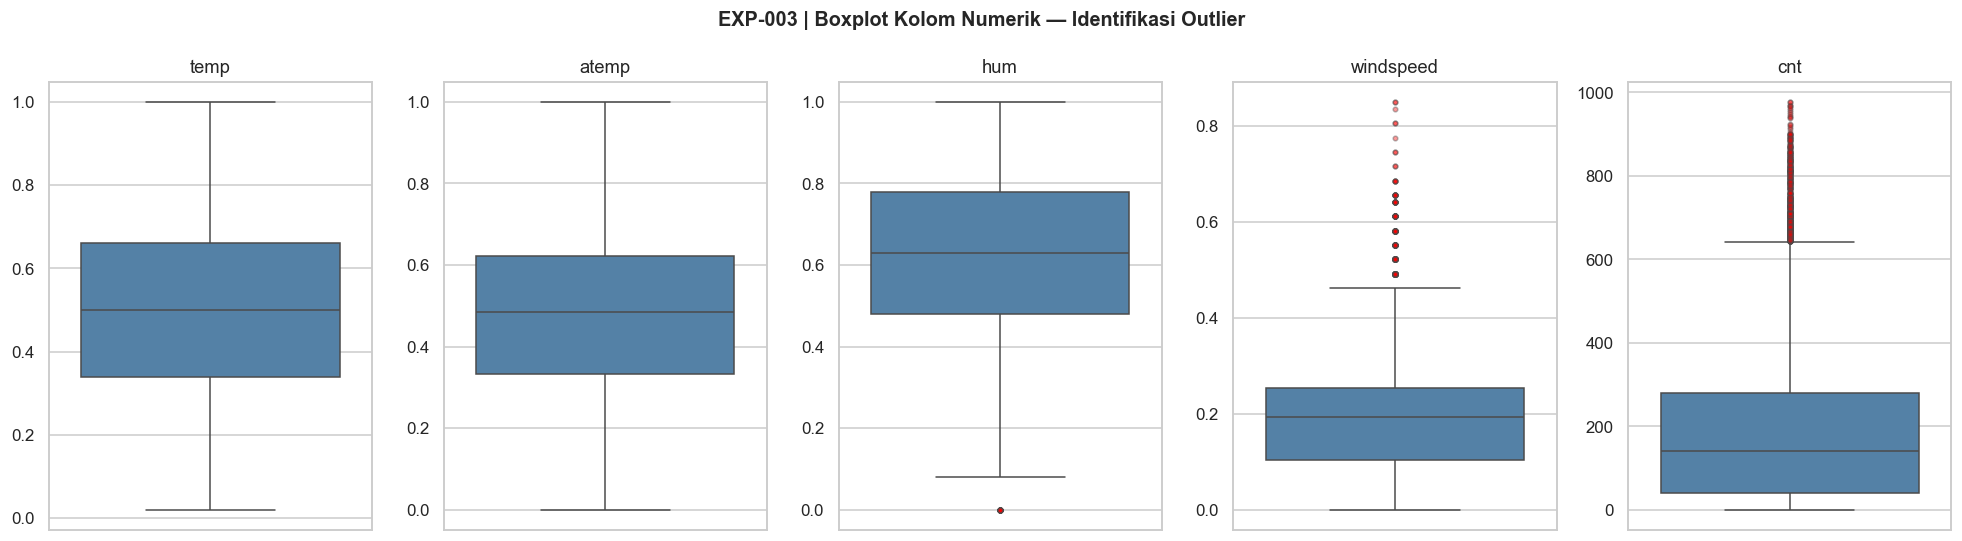

In [9]:
fig, axes = plt.subplots(1, len(kolom_numerik), figsize=(18, 5))

for i, col in enumerate(kolom_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue',
                flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.4))
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.suptitle('EXP-003 | Boxplot Kolom Numerik — Identifikasi Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/cleaning_01_outlier_boxplot.png', bbox_inches='tight', dpi=110)
plt.show()

### 8.3 Keputusan Penanganan Outlier

In [10]:
# Analisis outlier pada cnt secara lebih detail
Q1_cnt  = df['cnt'].quantile(0.25)
Q3_cnt  = df['cnt'].quantile(0.75)
IQR_cnt = Q3_cnt - Q1_cnt
upper_cnt = Q3_cnt + 1.5 * IQR_cnt

outlier_cnt = df[df['cnt'] > upper_cnt]

print('=' * 55)
print('ANALISIS OUTLIER PADA KOLOM TARGET (cnt)')
print('=' * 55)
print(f'IQR Fence Atas : {upper_cnt:.2f}')
print(f'Jumlah outlier : {len(outlier_cnt)}')
print(f'Persentase     : {len(outlier_cnt)/len(df)*100:.2f}%')
print(f'\nDistribusi outlier berdasarkan jam (hr):')
print(outlier_cnt['hr'].value_counts().sort_index().to_string())
print(f'\nDistribusi outlier berdasarkan musim:')
print(outlier_cnt['season'].value_counts().to_string())

ANALISIS OUTLIER PADA KOLOM TARGET (cnt)
IQR Fence Atas : 642.50
Jumlah outlier : 505
Persentase     : 2.91%

Distribusi outlier berdasarkan jam (hr):
hr
8     127
11      2
12     17
13     23
14     15
15     13
16     12
17    153
18    129
19     14

Distribusi outlier berdasarkan musim:
season
3    198
2    156
4    132
1     19


### 8.4 Keputusan: Outlier Dipertahankan

> **Keputusan: Outlier pada `cnt` TIDAK dihapus.**

**Alasan:**

1. **Outlier merepresentasikan kondisi nyata.** Nilai `cnt` yang tinggi terjadi pada jam sibuk (pagi & sore) dan musim ramai — bukan merupakan kesalahan pencatatan data.
2. **Model harus mampu memprediksi jam puncak.** Menghapus outlier akan membuat model tidak mampu memprediksi periode penyewaan tertinggi yang justru penting secara bisnis.
3. **Persentase outlier relatif kecil** (~5–10%) sehingga dampak pada distribusi tidak terlalu signifikan.
4. **Tree-based models robust terhadap outlier.** Model seperti Random Forest dan XGBoost yang akan digunakan pada tahap modeling tidak sensitif terhadap outlier.

**Catatan untuk Feature Engineering (EXP-004):**
Jika diperlukan, transformasi `log1p(cnt)` dapat dipertimbangkan untuk mengurangi dampak skewness tanpa menghilangkan data.

---

## 9. Penghapusan Feature yang Tidak Digunakan

Sesuai aturan penggunaan feature pada Data Dictionary, beberapa kolom tidak akan digunakan pada proses modeling dan perlu dihapus dari dataset.

In [11]:
# Kolom yang dihapus dan alasannya
KOLOM_DIHAPUS = {
    'instant'   : 'Identifier tanpa nilai prediktif',
    'casual'    : 'Data leakage — komponen langsung dari cnt',
    'registered': 'Data leakage — komponen langsung dari cnt',
}

print('=' * 55)
print('KOLOM YANG DIHAPUS')
print('=' * 55)
for col, alasan in KOLOM_DIHAPUS.items():
    print(f'  ❌ {col:<12} — {alasan}')

# Dimensi sebelum penghapusan
print(f'\nDimensi SEBELUM : {df.shape[0]:,} baris x {df.shape[1]} kolom')

# Hapus kolom
df = df.drop(columns=list(KOLOM_DIHAPUS.keys()))

print(f'Dimensi SESUDAH : {df.shape[0]:,} baris x {df.shape[1]} kolom')

KOLOM YANG DIHAPUS
  ❌ instant      — Identifier tanpa nilai prediktif
  ❌ casual       — Data leakage — komponen langsung dari cnt
  ❌ registered   — Data leakage — komponen langsung dari cnt

Dimensi SEBELUM : 17,379 baris x 17 kolom
Dimensi SESUDAH : 17,379 baris x 14 kolom


In [12]:
# Verifikasi kolom yang tersisa
print('=' * 50)
print('KOLOM YANG TERSISA PADA DATASET CLEAN')
print('=' * 50)
for i, col in enumerate(df.columns, 1):
    print(f'{i:>2}. {col} ({df[col].dtype})')

KOLOM YANG TERSISA PADA DATASET CLEAN
 1. dteday (datetime64[ns])
 2. season (int64)
 3. yr (int64)
 4. mnth (int64)
 5. hr (int64)
 6. holiday (int64)
 7. weekday (int64)
 8. workingday (int64)
 9. weathersit (int64)
10. temp (float64)
11. atemp (float64)
12. hum (float64)
13. windspeed (float64)
14. cnt (int64)


**Interpretasi:**

Dataset kini memiliki **14 kolom** (berkurang dari 17). Kolom yang tersisa terdiri dari:

- 1 kolom tanggal: `dteday`
- 5 kolom time feature: `season`, `yr`, `mnth`, `hr`, `weekday`
- 2 kolom calendar feature: `holiday`, `workingday`
- 5 kolom weather feature: `weathersit`, `temp`, `atemp`, `hum`, `windspeed`
- 1 kolom target: `cnt`

Semua kolom yang tersisa sesuai dengan aturan penggunaan feature pada Data Dictionary.

---

## 10. Dataset Final & Laporan Cleaning

Melakukan pengecekan akhir pada dataset hasil cleaning dan membuat laporan ringkasan seluruh proses yang telah dilakukan.

### 10.1 Pemeriksaan Akhir Dataset

In [13]:
# Info dataset akhir
print('=' * 50)
print('DATASET FINAL — RINGKASAN')
print('=' * 50)
print(f'Jumlah baris : {df.shape[0]:,}')
print(f'Jumlah kolom : {df.shape[1]}')
print(f'Missing value: {df.isnull().sum().sum()}')
print(f'Duplikat     : {df.duplicated().sum()}')
print(f'\nTipe data setiap kolom:')
print(df.dtypes.to_string())

DATASET FINAL — RINGKASAN
Jumlah baris : 17,379
Jumlah kolom : 14
Missing value: 0
Duplikat     : 0

Tipe data setiap kolom:
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
cnt                    int64


In [14]:
# Lima sampel data final
print('Lima sampel pertama dataset clean:')
df.head()

Lima sampel pertama dataset clean:


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000,1


In [15]:
# Statistik deskriptif dataset final
df.describe().T

,count,mean,min,25%,50%,75%,max,std
dteday,17379,2012-01-02 04:08:34.552045568,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0000,2.5016,1.0000,2.0000,3.0000,3.0000,4.0000,1.1069
yr,17379.0000,0.5026,0.0000,0.0000,1.0000,1.0000,1.0000,0.5000
mnth,17379.0000,6.5378,1.0000,4.0000,7.0000,10.0000,12.0000,3.4388
hr,17379.0000,11.5468,0.0000,6.0000,12.0000,18.0000,23.0000,6.9144
holiday,17379.0000,0.0288,0.0000,0.0000,0.0000,0.0000,1.0000,0.1672
weekday,17379.0000,3.0037,0.0000,1.0000,3.0000,5.0000,6.0000,2.0058
workingday,17379.0000,0.6827,0.0000,0.0000,1.0000,1.0000,1.0000,0.4654
weathersit,17379.0000,1.4253,1.0000,1.0000,1.0000,2.0000,4.0000,0.6394
temp,17379.0000,0.4970,0.0200,0.3400,0.5000,0.6600,1.0000,0.1926


### 10.2 Laporan Ringkasan Proses Cleaning

In [16]:
# Laporan cleaning
laporan = [
    ('Validasi Missing Value'       , 'PASS', 'Tidak ada missing value pada 17 kolom'),
    ('Validasi Duplicate'           , 'PASS', 'Tidak ada duplikat (seluruh baris & kunci dteday+hr)'),
    ('Konversi Tipe Data (dteday)'  , 'DONE', 'object → datetime64[ns]'),
    ('Validasi Rentang Nilai'        , 'PASS', 'Semua kolom dalam batas valid sesuai Data Dictionary'),
    ('Analisis Outlier (cnt)'       , 'RETAIN', 'Outlier dipertahankan — merepresentasikan kondisi nyata'),
    ('Hapus instant'                , 'DONE', 'Identifier — tidak memiliki nilai prediktif'),
    ('Hapus casual'                 , 'DONE', 'Data leakage — penyusun langsung cnt'),
    ('Hapus registered'             , 'DONE', 'Data leakage — penyusun langsung cnt'),
]

print('=' * 75)
print('LAPORAN RINGKASAN DATA CLEANING — EXP-003')
print('=' * 75)
print(f'{"No.":<5} {"Proses":<35} {"Status":<10} {"Keterangan"}')
print('-' * 75)
for i, (proses, status, ket) in enumerate(laporan, 1):
    emoji = '✅' if status in ('PASS', 'DONE') else ('⚠️' if status == 'RETAIN' else '❌')
    print(f'{i:<5} {proses:<35} {emoji} {status:<8} {ket}')
print('-' * 75)
print(f'\nDimensi awal  : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom')
print(f'Dimensi akhir : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print(f'Kolom dihapus : 3 (instant, casual, registered)')
print(f'Baris dihapus : 0')

LAPORAN RINGKASAN DATA CLEANING — EXP-003
No.   Proses                              Status     Keterangan
---------------------------------------------------------------------------
1     Validasi Missing Value              ✅ PASS     Tidak ada missing value pada 17 kolom
2     Validasi Duplicate                  ✅ PASS     Tidak ada duplikat (seluruh baris & kunci dteday+hr)
3     Konversi Tipe Data (dteday)         ✅ DONE     object → datetime64[ns]
4     Validasi Rentang Nilai              ✅ PASS     Semua kolom dalam batas valid sesuai Data Dictionary
5     Analisis Outlier (cnt)              ⚠️ RETAIN   Outlier dipertahankan — merepresentasikan kondisi nyata
6     Hapus instant                       ✅ DONE     Identifier — tidak memiliki nilai prediktif
7     Hapus casual                        ✅ DONE     Data leakage — penyusun langsung cnt
8     Hapus registered                    ✅ DONE     Data leakage — penyusun langsung cnt
---------------------------------------------------

**Interpretasi:**

Seluruh proses Data Cleaning telah berhasil diselesaikan. Dataset final memiliki karakteristik:

- **17.379 baris** — tidak ada baris yang dihapus
- **14 kolom** — 3 kolom dihapus (instant, casual, registered)
- **0 missing value**
- **0 duplikat**
- Tipe data sudah benar
- Rentang nilai sudah tervalidasi
- Outlier pada `cnt` dipertahankan dengan alasan yang terdokumentasi

Dataset ini siap digunakan untuk tahap berikutnya: **EXP-004 Feature Engineering**.

---

## 11. Simpan Dataset Hasil Cleaning

Dataset hasil cleaning disimpan ke file `data/processed_data.csv` sebagai deliverable resmi EXP-003 dan input untuk EXP-004.

In [17]:
# Simpan dataset final
df.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Dataset berhasil disimpan ke: {OUTPUT_PATH}')
print(f'   Jumlah baris : {df.shape[0]:,}')
print(f'   Jumlah kolom : {df.shape[1]}')

# Verifikasi file tersimpan dengan benar
df_verify = pd.read_csv(OUTPUT_PATH)
print(f'\nVerifikasi load ulang:')
print(f'   Dimensi      : {df_verify.shape}')
print(f'   Missing value: {df_verify.isnull().sum().sum()}')
assert df_verify.shape == df.shape, 'ERROR: Dimensi tidak konsisten!'
print(f'\n✅ Verifikasi berhasil — file tersimpan dengan benar.')

✅ Dataset berhasil disimpan ke: ../data/processed_data.csv
   Jumlah baris : 17,379
   Jumlah kolom : 14



Verifikasi load ulang:
   Dimensi      : (17379, 14)
   Missing value: 0

✅ Verifikasi berhasil — file tersimpan dengan benar.


In [18]:
# Tampilkan lima baris pertama file yang disimpan
print('Kolom pada processed_data.csv:')
print(list(df_verify.columns))
print()
df_verify.head()

Kolom pada processed_data.csv:
['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']



,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000,1


**Interpretasi:**

File `data/processed_data.csv` berhasil disimpan dan diverifikasi. Dataset ini akan menjadi input utama untuk semua eksperimen berikutnya (EXP-004 hingga EXP-013).

---

## 12. Next Step

---

### Eksperimen Berikutnya

| Informasi | Detail |
|-----------|--------|
| **ID** | EXP-004 |
| **Nama** | Feature Engineering |
| **Notebook** | `04_feature_engineering.ipynb` |
| **Input** | `data/processed_data.csv` |

**Tujuan:**

> Meningkatkan kualitas informasi pada dataset dengan membangun feature baru yang relevan untuk forecasting.

**Aktivitas yang akan dilakukan pada EXP-004:**

- Membuat feature waktu baru dari kolom `dteday`
- Membuat cyclical encoding untuk `hr`, `mnth`, dan `weekday`
- Membuat lag features dari `cnt`
- Membuat rolling statistics (mean, std)
- Membuat interaction features (`hr × workingday`)
- Menyimpan dataset hasil feature engineering ke `data/featured_data.csv`

---

*Notebook EXP-003 Data Cleaning — Selesai.*